In [31]:
# ==============================
# STEP 1 — Global Imports
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [32]:
# ==============================================================
# STEP 2 — DATASET 2: Generative AI with CTGAN 
# ==============================================================

import pandas as pd
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata
from IPython.display import display

# -------------------------------
# 1. Load the real dataset
# -------------------------------
df_real = pd.read_csv("voice.csv")

# Encode label (male=0, female=1)
df_real['label'] = df_real['label'].map({'male': 0, 'female': 1})

# -------------------------------
# 2. Define metadata
# -------------------------------
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data=df_real)

# -------------------------------
# 3. Initialize CTGAN model
# -------------------------------
ctgan = CTGANSynthesizer(
    metadata,
    epochs=300
)

# -------------------------------
# 4. Train the model on real data
# -------------------------------
ctgan.fit(df_real)

# -------------------------------
# 5. Generate synthetic dataset
# -------------------------------
df2 = ctgan.sample(num_rows=500)

# -------------------------------
# 6. Post-processing
# -------------------------------
# Ensure label is integer (0 or 1)
df2['label'] = df2['label'].round().astype(int)

# Shuffle dataset for randomness
df2 = df2.sample(frac=1, random_state=42).reset_index(drop=True)

# -------------------------------
# 7. Display results (clean format)
# -------------------------------
print("=" * 50)
print("🧪 STEP 2 — DATASET 2: CTGAN Generation")
print("=" * 50)

# Display first rows
display(df2.head())

# Dataset shape
print(f"\n📐 Shape   : {df2.shape[0]} rows × {df2.shape[1]} columns")

# Data types summary
dtype_counts = df2.dtypes.value_counts()
print("\n📊 Column Types:")
for dtype, count in dtype_counts.items():
    print(f"   - {dtype}: {count} columns")

# Label distribution
label_counts = df2['label'].value_counts()
print("\n🏷️ Label Distribution:")
for label, count in label_counts.items():
    print(f"   - {label}: {count}")

# Label ratio (percentage)
print("\n📈 Label Ratio (%):")
print((df2['label'].value_counts(normalize=True) * 100).round(2))

df2.to_csv("voice_synthetic.csv", index=False)

🧪 STEP 2 — DATASET 2: CTGAN Generation


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.220270,0.024649,0.208822,0.247347,0.240914,0.022108,2.502815,11.729122,0.801251,0.213335,...,0.236841,0.161737,0.013399,0.279114,0.106929,0.154372,10.967674,11.510780,0.113989,1
1,0.193723,0.031221,0.204330,0.211500,0.223816,0.060947,2.368960,21.746882,0.887775,0.077104,...,0.239612,0.176243,0.015794,0.273914,0.009810,0.014014,2.670682,6.957074,0.195392,1
2,0.137475,0.098646,0.186383,0.122108,0.256626,0.102339,2.456030,19.149851,0.921913,0.806765,...,0.164572,0.057242,0.035765,0.208786,0.257001,0.010184,4.767198,6.486182,0.041428,0
3,0.226915,0.036632,0.159442,0.247347,0.232225,0.024575,5.840813,13.966152,0.772640,0.152577,...,0.238523,0.200414,0.015716,0.279114,0.019744,0.038015,3.983372,0.370056,0.122281,1
4,0.197725,0.022363,0.194573,0.166626,0.242278,0.032580,3.726658,10.368421,0.829219,0.108312,...,0.224978,0.156173,0.023342,0.254412,0.793580,0.029604,1.325076,5.374066,0.188097,1



📐 Shape   : 500 rows × 21 columns

📊 Column Types:
   - float64: 20 columns
   - int64: 1 columns

🏷️ Label Distribution:
   - 1: 252
   - 0: 248

📈 Label Ratio (%):
label
1    50.4
0    49.6
Name: proportion, dtype: float64


In [33]:
# ==============================================================
# STEP 3 — Loading & Preparing Dataset 1
# ==============================================================
import pandas as pd
from IPython.display import display, HTML

df = pd.read_csv("voice.csv")

# ------ DATASET DESCRIPTION CARD ------
html_desc = """
<div style="font-family:sans-serif; padding:16px; border:1px solid #e0e0e0;
            border-radius:10px; background:#fafafa; max-width:820px;">

  <div style="display:flex; justify-content:space-between;
              align-items:center; margin-bottom:14px;">
    <div>
      <span style="font-size:17px; font-weight:600;">
        Gender Recognition by Voice
      </span>
      <span style="margin-left:10px; font-size:12px; color:#888;">
        Kory Becker — Kaggle
      </span>
    </div>
    <a href="https://www.kaggle.com/datasets/primaryobjects/voicegender"
       target="_blank"
       style="font-size:12px; color:#20beff; text-decoration:none;
              border:1px solid #20beff; padding:5px 12px; border-radius:6px;">
      Open on Kaggle
    </a>
  </div>

  <div style="display:grid; grid-template-columns:repeat(4,1fr);
              gap:10px; margin-bottom:14px;">
    <div style="background:#fff; border:1px solid #e8e8e8; border-radius:8px;
                padding:10px; text-align:center;">
      <div style="font-size:22px; font-weight:600; color:#333;">3168</div>
      <div style="font-size:11px; color:#888; margin-top:2px;">Total samples</div>
    </div>
    <div style="background:#fff; border:1px solid #e8e8e8; border-radius:8px;
                padding:10px; text-align:center;">
      <div style="font-size:22px; font-weight:600; color:#333;">20</div>
      <div style="font-size:11px; color:#888; margin-top:2px;">Acoustic features</div>
    </div>
    <div style="background:#fff; border:1px solid #e8e8e8; border-radius:8px;
                padding:10px; text-align:center;">
      <div style="font-size:22px; font-weight:600; color:#333;">50 / 50</div>
      <div style="font-size:11px; color:#888; margin-top:2px;">Male / Female</div>
    </div>
    <div style="background:#fff; border:1px solid #e8e8e8; border-radius:8px;
                padding:10px; text-align:center;">
      <div style="font-size:22px; font-weight:600; color:#333;">0</div>
      <div style="font-size:11px; color:#888; margin-top:2px;">Missing values</div>
    </div>
  </div>

  <div style="margin-bottom:14px;">
    <div style="font-size:12px; color:#888; margin-bottom:5px;">
      Label distribution
    </div>
    <div style="display:flex; height:26px; border-radius:6px; overflow:hidden;">
      <div style="width:50%; background:#1D9E75; display:flex;
                  align-items:center; justify-content:center;">
        <span style="font-size:11px; color:#fff; font-weight:500;">
          Male — 1584
        </span>
      </div>
      <div style="width:50%; background:#534AB7; display:flex;
                  align-items:center; justify-content:center;">
        <span style="font-size:11px; color:#fff; font-weight:500;">
          Female — 1584
        </span>
      </div>
    </div>
  </div>

  <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px;">

    <div style="font-size:12px; color:#555; line-height:1.7;
                padding:10px 14px; background:#fff;
                border-left:3px solid #534AB7; border-radius:0 8px 8px 0;">
      Voice samples processed with R <code>seewave</code> and <code>tuneR</code> packages.
      Acoustic features extracted from <strong>0.01 to 280 Hz</strong> frequency range.
      Task: binary classification — <strong>male (0)</strong> vs <strong>female (1)</strong>.
    </div>

    <div style="font-size:12px; color:#555; line-height:1.7;
                padding:10px 14px; background:#fff;
                border-left:3px solid #1D9E75; border-radius:0 8px 8px 0;">
      No dataset was specified in the project. After research on Kaggle,
      OpenML and GitHub, we selected this one — perfectly balanced,
      0 missing values, and cited in published ML research papers.
    </div>

  </div>

</div>
"""
display(HTML(html_desc))

# ------ EXPLORE THE DATASET ------
print("\n📋 First 5 rows:")
display(df.head())

print(f"\n📐 Shape   : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"📊 Types   : {df.dtypes.nunique()} dtype(s) — all float64 except label (object)")

print("\n📈 Descriptive statistics:")
display(df.describe().round(4))

print("\n🔖 Label distribution:")
print(df['label'].value_counts())

# ------ CLEANING ------
print("\n--- Cleaning ---")

# Check for missing values in each column
print("Missing values :", df.isnull().sum().sum(), "total")

# Check for duplicate rows
print("Duplicate rows :", df.duplicated().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)
print("Shape after cleaning:", df.shape)

# Encode label: male=0, female=1
df['label'] = df['label'].map({'male': 0, 'female': 1})
print("\nFinal class distribution:\n", df['label'].value_counts())


📋 First 5 rows:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male



📐 Shape   : 3168 rows × 21 columns
📊 Types   : 2 dtype(s) — all float64 except label (object)

📈 Descriptive statistics:


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx
count,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000,3168.0000
mean,0.1809,0.0571,0.1856,0.1405,0.2248,0.0843,3.1402,36.5685,0.8951,0.4082,0.1653,0.1809,0.1428,0.0368,0.2588,0.8292,0.0526,5.0473,4.9946,0.1738
std,0.0299,0.0167,0.0364,0.0487,0.0236,0.0428,4.2405,134.9287,0.0450,0.1775,0.0772,0.0299,0.0323,0.0192,0.0301,0.5252,0.0633,3.5212,3.5200,0.1195
min,0.0394,0.0184,0.0110,0.0002,0.0429,0.0146,0.1417,2.0685,0.7387,0.0369,0.0000,0.0394,0.0556,0.0098,0.1031,0.0078,0.0049,0.0078,0.0000,0.0000
25%,0.1637,0.0420,0.1696,0.1111,0.2087,0.0426,1.6496,5.6695,0.8618,0.2580,0.1180,0.1637,0.1170,0.0182,0.2540,0.4198,0.0078,2.0703,2.0449,0.0998
50%,0.1848,0.0592,0.1900,0.1403,0.2257,0.0943,2.1971,8.3185,0.9018,0.3963,0.1866,0.1848,0.1405,0.0461,0.2712,0.7658,0.0234,4.9922,4.9453,0.1394
75%,0.1991,0.0670,0.2106,0.1759,0.2437,0.1142,2.9317,13.6489,0.9287,0.5337,0.2211,0.1991,0.1696,0.0479,0.2775,1.1772,0.0703,7.0078,6.9922,0.2092
max,0.2511,0.1153,0.2612,0.2473,0.2735,0.2522,34.7255,1309.6129,0.9820,0.8429,0.2800,0.2511,0.2376,0.2041,0.2791,2.9577,0.4590,21.8672,21.8438,0.9324



🔖 Label distribution:
label
male      1584
female    1584
Name: count, dtype: int64

--- Cleaning ---
Missing values : 0 total
Duplicate rows : 2
Shape after cleaning: (3166, 21)

Final class distribution:
 label
0    1583
1    1583
Name: count, dtype: int64


In [34]:
# ==============================================================
# STEP 4 — Feature Engineering (PCA + LDA)
# Here we only display the information; PCA will be applied after the split
# ==============================================================
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler

X = df.drop('label', axis=1).values
y = df['label'].values
feature_names = df.drop('label', axis=1).columns.tolist()

# Temporary scaler just to visualize PCA/LDA (not used for training)
scaler_viz = StandardScaler()
X_viz = scaler_viz.fit_transform(X)

pca_viz = PCA(n_components=2)
X_pca_viz = pca_viz.fit_transform(X_viz)

lda_viz = LDA(n_components=1)
X_lda_viz = lda_viz.fit_transform(X_viz, y)

print("=" * 50)
print("STEP 4 — Feature Engineering")
print("=" * 50)
print("Shape X:", X.shape)
print("\nPCA 2 components — explained variance:")
for i, v in enumerate(pca_viz.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.4f} ({v*100:.1f}%)")
print(f"  Total: {sum(pca_viz.explained_variance_ratio_):.4f}")

# Top features LDA
importance_lda = np.abs(lda_viz.coef_[0])
top_idx = np.argsort(importance_lda)[::-1][:5]
print("\nTop 5 discriminative features (LDA):")
for i, idx in enumerate(top_idx):
    print(f"  {i+1}. {feature_names[idx]}: {importance_lda[idx]:.4f}")
print()


STEP 4 — Feature Engineering
Shape X: (3166, 20)

PCA 2 components — explained variance:
  PC1: 0.4522 (45.2%)
  PC2: 0.1187 (11.9%)
  Total: 0.5709

Top 5 discriminative features (LDA):
  1. meanfun: 8.2316
  2. skew: 2.7875
  3. IQR: 1.9671
  4. Q75: 1.5000
  5. sfm: 1.3967



In [35]:
# ==============================================================
# STEP 5 — Data Splitting
# ==============================================================
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("=" * 50)
print("STEP 5 — Data Splitting")
print("=" * 50)

# --- Method 1: Train / Validation / Test on Dataset 1 ---
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)
# 0.1765 * 0.85 ≈ 0.15 → val = 15%

print("Method 1 (Dataset 1) — Train / Val / Test:")
print(f"  Train : {X_train_raw.shape[0]} ({X_train_raw.shape[0]/len(X)*100:.0f}%)")
print(f"  Val   : {X_val_raw.shape[0]} ({X_val_raw.shape[0]/len(X)*100:.0f}%)")
print(f"  Test  : {X_test_raw.shape[0]} ({X_test_raw.shape[0]/len(X)*100:.0f}%)")

# Scaler fitted ONLY on train — applied on val and test (no data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

# PCA fitted ONLY on train (10 components ≈ 95% variance)
pca = PCA(n_components=10, random_state=42)
X_train = pca.fit_transform(X_train)
X_val   = pca.transform(X_val)
X_test  = pca.transform(X_test)

print(f"\n  After PCA (10 components):")
print(f"  Total explained variance : {sum(pca.explained_variance_ratio_):.4f}")
print(f"  X_train shape            : {X_train.shape}")

# --- Method 2: StratifiedKFold on Dataset 2  (display only) ---
X2_raw = df2[feature_names].values
y2     = df2['label'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nMethod 2 (Dataset 2) — StratifiedKFold (k=5):")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X2_raw, y2)):
    print(f"  Fold {fold+1}: train={len(tr_idx)}, test={len(val_idx)}")

print("  → Cross-validation shown for methodology only (not used for training)")

STEP 5 — Data Splitting
Method 1 (Dataset 1) — Train / Val / Test:
  Train : 2216 (70%)
  Val   : 475 (15%)
  Test  : 475 (15%)

  After PCA (10 components):
  Total explained variance : 0.9599
  X_train shape            : (2216, 10)

Method 2 (Dataset 2) — StratifiedKFold (k=5):
  Fold 1: train=400, test=100
  Fold 2: train=400, test=100
  Fold 3: train=400, test=100
  Fold 4: train=400, test=100
  Fold 5: train=400, test=100
  → Cross-validation shown for methodology only (not used for training)


In [36]:
# ==============================================================
# STEP 6 — Algorithm Selection
# ==============================================================
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

print("=" * 50)
print("STEP 6 — Algorithm Selection")
print("=" * 50)
print("  ML: Random Forest, SVM, Logistic Regression, Gradient Boosting")
print("  DL: MLP (Multi-Layer Perceptron)")
print()

STEP 6 — Algorithm Selection
  ML: Random Forest, SVM, Logistic Regression, Gradient Boosting
  DL: MLP (Multi-Layer Perceptron)



In [37]:
# ==============================================================
# STEP 7 — Training + Comparison on Validation
# ==============================================================
from sklearn.metrics import accuracy_score

print("=" * 50)
print("STEP 7 — Training and Evaluation (validation set)")
print("=" * 50)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'MLP (DL)':            MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                         activation='relu', max_iter=500,
                                         random_state=42),
}

val_results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, m.predict(X_val))
    val_results[name] = val_acc
    print(f"  {name:<25} Val Accuracy: {val_acc:.4f}")

best_name = max(val_results, key=val_results.get)
best_model = models[best_name]
print(f"\n  → Best model: {best_name} ({val_results[best_name]:.4f})")
print()


STEP 7 — Training and Evaluation (validation set)
  Logistic Regression       Val Accuracy: 0.9726
  Random Forest             Val Accuracy: 0.9684
  SVM (RBF)                 Val Accuracy: 0.9768
  Gradient Boosting         Val Accuracy: 0.9684
  MLP (DL)                  Val Accuracy: 0.9642

  → Best model: SVM (RBF) (0.9768)



STEP 8 — Final Evaluation on (Test Set)
  Test Accuracy : 0.9747
  AUC-ROC       : 0.9938

Classification Report:
              precision    recall  f1-score   support

        male       0.99      0.96      0.97       238
      female       0.96      0.99      0.98       237

    accuracy                           0.97       475
   macro avg       0.98      0.97      0.97       475
weighted avg       0.98      0.97      0.97       475

Confusion Matrix:
[[228  10]
 [  2 235]]


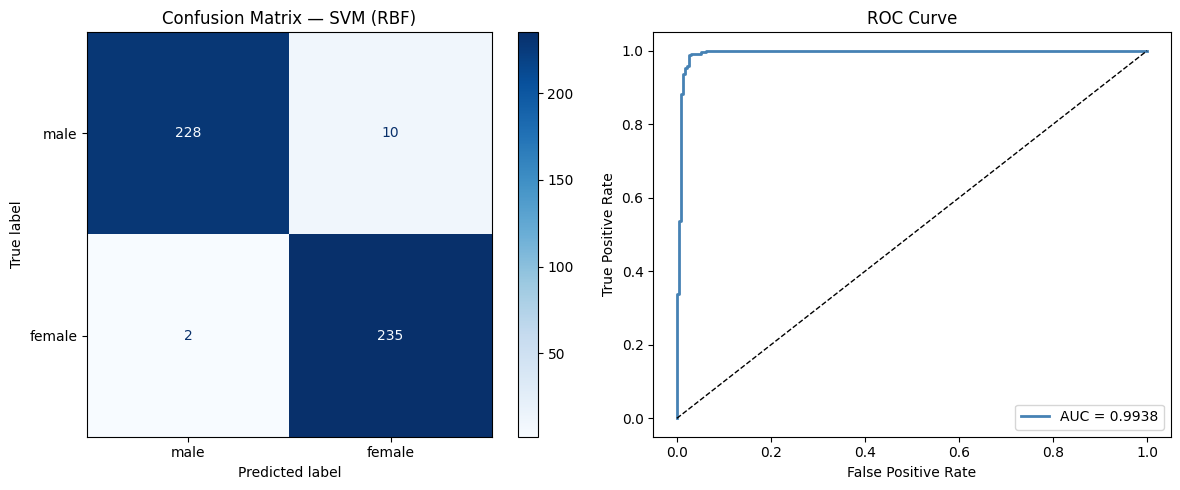

In [38]:
# ==============================================================
# STEP 8 — Final Evaluation on Test Set
# ==============================================================
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

print("=" * 50)
print("STEP 8 — Final Evaluation on (Test Set)")
print("=" * 50)

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
# AUC-ROC = measures the model's ability to distinguish classes; closer to 1 = better
auc      = roc_auc_score(y_test, y_proba)

print(f"  Test Accuracy : {test_acc:.4f}")
print(f"  AUC-ROC       : {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['male', 'female']))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Confusion matrix
ConfusionMatrixDisplay(cm, display_labels=['male', 'female']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title(f'Confusion Matrix — {best_name}')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print()


In [39]:
# ==============================================================
# STEP 9 — Results Analysis + Stability Test on Dataset 2
# ==============================================================
import numpy as np

print("=" * 50)
print("STEP 9 — Results Analysis")
print("=" * 50)

# --- Part A: Feature Importance (Random Forest) ---
rf_raw = RandomForestClassifier(n_estimators=200, random_state=42)
rf_raw.fit(X_train_raw, y_train)  # X_train_raw — no scaler needed for RF

feat_importance = pd.DataFrame({
    'feature':    feature_names,
    'importance': rf_raw.feature_importances_
}).sort_values('importance', ascending=False)

print("\n  Top 10 features (Random Forest):")
print(feat_importance.head(10).to_string(index=False))

# --- Part B: Stability Test — D1 model tested on D2 ---
print("\n  --- Stability test: D1 model → Dataset 2 ---")

# Apply SAME scaler + PCA from D1 (no refit — avoids data leakage)
X2_scaled = scaler.transform(X2_raw)
X2_pca    = pca.transform(X2_scaled)
print(f"  Shape X2_pca : {X2_pca.shape}")

# Overall accuracy on full D2
acc_d2 = accuracy_score(y2, best_model.predict(X2_pca))
print(f"\n  Accuracy D1 model on full Dataset 2 : {acc_d2:.4f}")



print("\n" + "=" * 50)
print("  STEP 9 SUMMARY")
print("=" * 50)
print(f"  D1 model on Test set  : {test_acc:.4f}")
print(f"  D1 model on Dataset 2 : {acc_d2:.4f}")
print()
print("  → Dataset 2 is used as an external test set to evaluate the generalization performance of the model trained on Dataset 1.")

STEP 9 — Results Analysis

  Top 10 features (Random Forest):
 feature  importance
 meanfun    0.338342
     IQR    0.239808
     Q25    0.127772
      sd    0.076108
  sp.ent    0.036282
     sfm    0.030451
centroid    0.018762
    mode    0.018735
meanfreq    0.016873
  median    0.014795

  --- Stability test: D1 model → Dataset 2 ---
  Shape X2_pca : (500, 10)

  Accuracy D1 model on full Dataset 2 : 0.8680

  STEP 9 SUMMARY
  D1 model on Test set  : 0.9747
  D1 model on Dataset 2 : 0.8680

  → Dataset 2 is used as an external test set to evaluate the generalization performance of the model trained on Dataset 1.


STEP 10 — Model Enhancement (Hyperparameter Tuning)
  Best model from Step 7 : SVM (RBF)
  Applying GridSearchCV on : SVM (RBF)...

  Best hyperparameters  : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
  Best CV score (train) : 0.9788

  Accuracy BEFORE tuning (SVM (RBF)) : 0.9747
  Accuracy AFTER  tuning (SVM (RBF)) : 0.9768
  AUC AFTER tuning                     : 0.9948

  Classification Report (After tuning):
              precision    recall  f1-score   support

        male       0.99      0.96      0.98       238
      female       0.96      0.99      0.98       237

    accuracy                           0.98       475
   macro avg       0.98      0.98      0.98       475
weighted avg       0.98      0.98      0.98       475



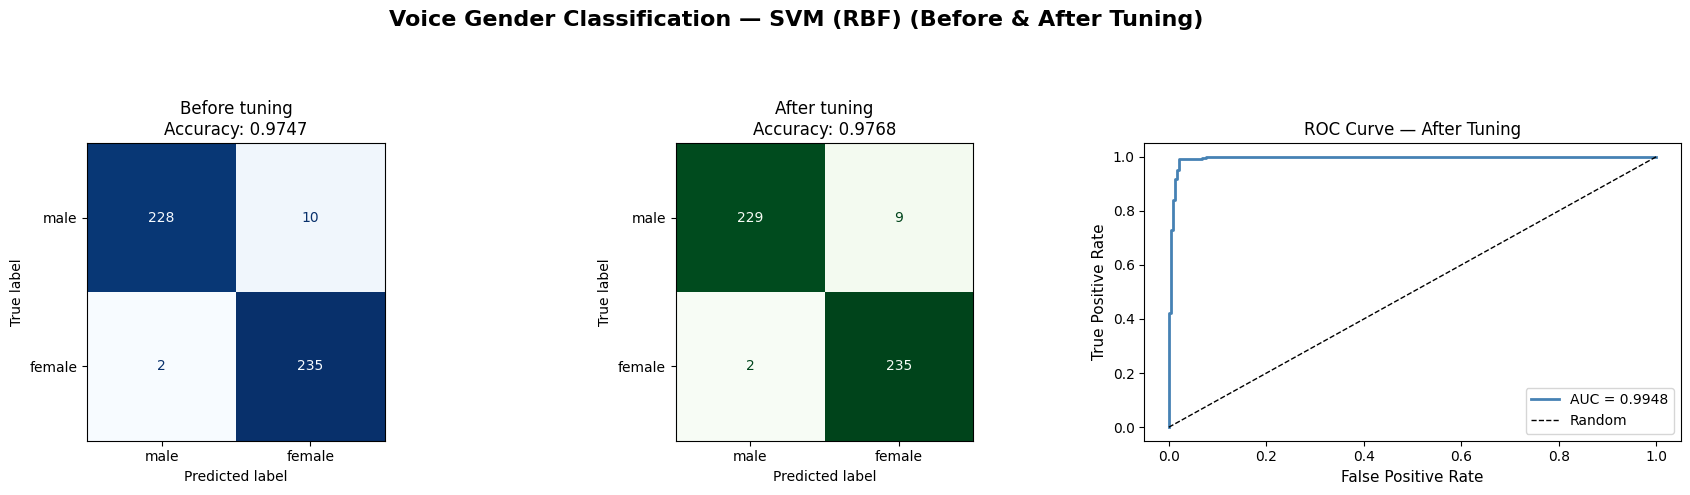

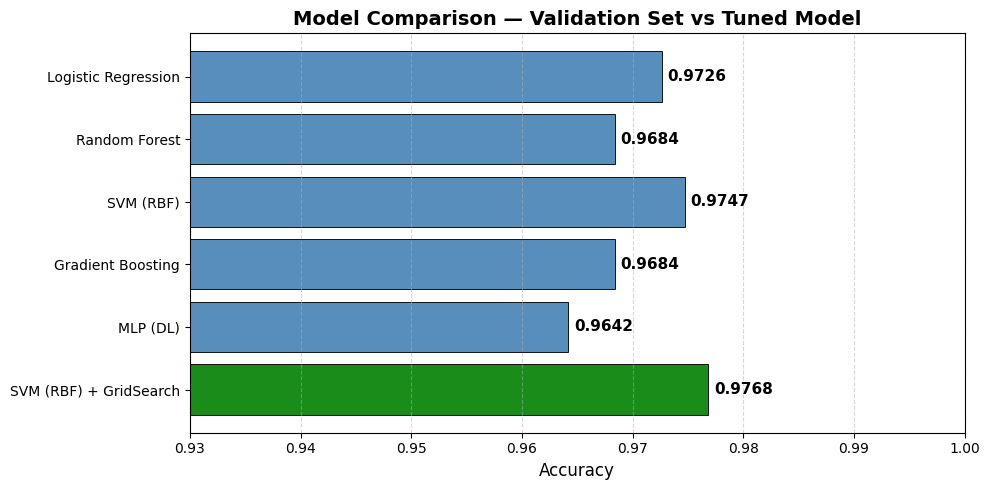


PROJECT COMPLETED
  Final model      : SVM (RBF) + GridSearchCV
  Best parameters  : {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
  Accuracy BEFORE  : 0.9747
  Accuracy AFTER   : 0.9768
  AUC-ROC          : 0.9948
  Top feature      : meanfun


In [40]:
# ==============================================================
# STEP 10 — Model Enhancement (Hyperparameter Tuning)
# ==============================================================
from sklearn.model_selection import GridSearchCV

print("=" * 50)
print("STEP 10 — Model Enhancement (Hyperparameter Tuning)")
print("=" * 50)
print(f"  Best model from Step 7 : {best_name}")
print(f"  Applying GridSearchCV on : {best_name}...")

# ------ PARAM GRIDS — one per possible winner ------
param_grids = {
    'SVM (RBF)': {
        'C':      [1, 10, 50, 100],
        'gamma':  ['scale', 'auto', 0.01, 0.001],
        'kernel': ['rbf', 'linear'],
    },
    'Random Forest': {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 10, 20],
        'min_samples_split': [2, 5],
    },
    'Gradient Boosting': {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 5],
    },
    'Logistic Regression': {
        'C':        [0.01, 0.1, 1, 10],
        'solver':   ['lbfgs', 'liblinear'],
        'max_iter': [500, 1000],
    },
    'MLP (DL)': {
        'hidden_layer_sizes': [(64, 32), (128, 64), (128, 64, 32)],
        'activation':         ['relu', 'tanh'],
        'max_iter':           [300, 500],
    },
}

# ------ GRIDSEARCH DIRECTLY ON best_model FROM STEP 7 ------
gs = GridSearchCV(
    best_model,                  # ← directement récupéré de Step 7
    param_grids[best_name],      # ← param grid correspondant au gagnant
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gs.fit(X_train, y_train)

print(f"\n  Best hyperparameters  : {gs.best_params_}")
print(f"  Best CV score (train) : {gs.best_score_:.4f}")

# ------ COMPARE BEFORE vs AFTER ------
acc_before = accuracy_score(y_test, best_model.predict(X_test))   # ← score validation Step 7

best_final    = gs.best_estimator_
y_pred_final  = best_final.predict(X_test)
y_proba_final = best_final.predict_proba(X_test)[:, 1]
acc_final     = accuracy_score(y_test, y_pred_final)
auc_final     = roc_auc_score(y_test, y_proba_final)

print(f"\n  Accuracy BEFORE tuning ({best_name}) : {acc_before:.4f}")
print(f"  Accuracy AFTER  tuning ({best_name}) : {acc_final:.4f}")
print(f"  AUC AFTER tuning                     : {auc_final:.4f}")
print(f"\n  Classification Report (After tuning):")
print(classification_report(y_test, y_pred_final, target_names=['male', 'female']))



# --------------------------------------------------
# VISUALIZATION — Enhanced Design
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.subplots_adjust(top=0.85)  # espace pour le suptitle
fig.suptitle(f'Voice Gender Classification — {best_name} (Before & After Tuning)', fontsize=16, fontweight='bold')

# 1. Confusion Matrix BEFORE tuning
cm_before = confusion_matrix(y_test, best_model.predict(X_test))
ConfusionMatrixDisplay(cm_before, display_labels=['male', 'female']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Before tuning\nAccuracy: {acc_before:.4f}', fontsize=12, fontweight='medium')

# 2. Confusion Matrix AFTER tuning
cm_after = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm_after, display_labels=['male', 'female']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'After tuning\nAccuracy: {acc_final:.4f}', fontsize=12, fontweight='medium')

# 3. ROC Curve AFTER tuning
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
axes[2].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_final:.4f}')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[2].set_xlabel('False Positive Rate', fontsize=11)
axes[2].set_ylabel('True Positive Rate', fontsize=11)
axes[2].set_title(f'ROC Curve — After Tuning', fontsize=12, fontweight='medium')
axes[2].legend(fontsize=10, loc='lower right')

plt.tight_layout(rect=[0, 0, 1, 0.9])  # ajuste le layout pour le suptitle
plt.savefig('model_evaluation_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# MODEL COMPARISON — Enhanced Design
# --------------------------------------------------

val_results_plot = val_results.copy()
val_results_plot[f'{best_name} + GridSearch'] = acc_final
val_results_plot[f'{best_name}'] = acc_before  # score original

plt.figure(figsize=(10, 5))

# Couleurs : vert pour le modèle final
colors = ['steelblue'] * (len(val_results_plot)-1) + ['green']

bars = plt.barh(list(val_results_plot.keys()), list(val_results_plot.values()), 
                color=colors, alpha=0.9, edgecolor='black', linewidth=0.7)

# Zoom X-axis à partir de 0.93
plt.xlim(0.93, 1.0)
plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Comparison — Validation Set vs Tuned Model', fontsize=14, fontweight='bold')

# Ajouter valeurs sur les barres avec style
for i, (name, score) in enumerate(val_results_plot.items()):
    plt.text(score + 0.0005, i, f'{score:.4f}', va='center', fontsize=11, fontweight='bold', color='black')

plt.gca().invert_yaxis()  # meilleur modèle en haut
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# FINAL SUMMARY
# --------------------------------------------------
print("\n" + "=" * 50)
print("PROJECT COMPLETED")
print("=" * 50)

print(f"  Final model      : {best_name} + GridSearchCV")
print(f"  Best parameters  : {gs.best_params_}")
print(f"  Accuracy BEFORE  : {acc_before:.4f}")
print(f"  Accuracy AFTER   : {acc_final:.4f}")
print(f"  AUC-ROC          : {auc_final:.4f}")

# Top feature
top_feature = feat_importance.iloc[0]['feature']
print(f"  Top feature      : {top_feature}")

print("=" * 50)